This file analyses the compounded return, as well as the risk-adjusted return of 4 assets
from different industries and compares them to the performance of S&P 500 over the past 5 years

Assets used: Apple, JP Morgan, Coca-Cola, Exxon Mobil


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import os


os.makedirs("returns_charts", exist_ok=True)

end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL","JPM","KO","XOM", "^GSPC"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df.round(3)

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JPM,KO,XOM,^GSPC
Date,,,,,
2021-05-21,122.263,143.353,47.060,49.025,4155.86
2021-05-24,123.891,144.128,47.215,49.600,4197.05
2021-05-25,123.696,142.639,47.206,48.476,4188.13
2021-05-26,123.647,142.621,47.413,49.042,4195.99
2021-05-27,122.117,144.842,47.809,48.726,4200.88
...,...,...,...,...,...
2026-05-13,298.870,300.250,80.260,150.548,7444.25
2026-05-14,298.210,299.910,80.450,151.750,7501.24
2026-05-15,300.230,297.810,80.820,157.920,7408.50


In [6]:
returns = df.pct_change().dropna()
returns.round(4)

Ticker,AAPL,JPM,KO,XOM,^GSPC
Date,,,,,
2021-05-24,0.0133,0.0054,0.0033,0.0117,0.0099
2021-05-25,-0.0016,-0.0103,-0.0002,-0.0226,-0.0021
2021-05-26,-0.0004,-0.0001,0.0044,0.0117,0.0019
2021-05-27,-0.0124,0.0156,0.0084,-0.0064,0.0012
2021-05-28,-0.0053,-0.0007,-0.0036,-0.0032,0.0008
...,...,...,...,...,...
2026-05-13,0.0138,-0.0152,0.0029,0.0062,0.0058
2026-05-14,-0.0022,-0.0011,0.0024,0.0080,0.0077
2026-05-15,0.0068,-0.0070,0.0046,0.0407,-0.0124


In [7]:
avg_returns = returns.mean()
annual_returns = (1+avg_returns)**252 - 1
annual_returns.round(3)

Ticker
AAPL     0.243
JPM      0.192
KO       0.132
XOM      0.319
^GSPC    0.138
dtype: float64

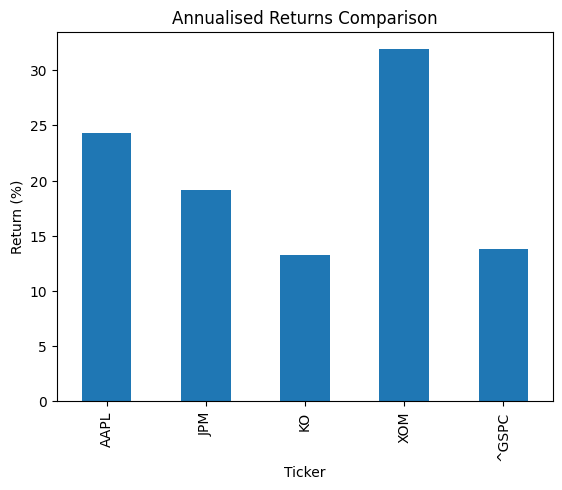

In [8]:
(annual_returns*100).plot(kind='bar')
plt.title('Annualised Returns Comparison')
plt.ylabel('Return (%)')
plt.savefig("returns_charts/annualised_returns.png")

In [9]:
annual_volatility = returns.std()*252**0.5
annual_volatility.round(3)

Ticker
AAPL     0.274
JPM      0.244
KO       0.160
XOM      0.267
^GSPC    0.169
dtype: float64

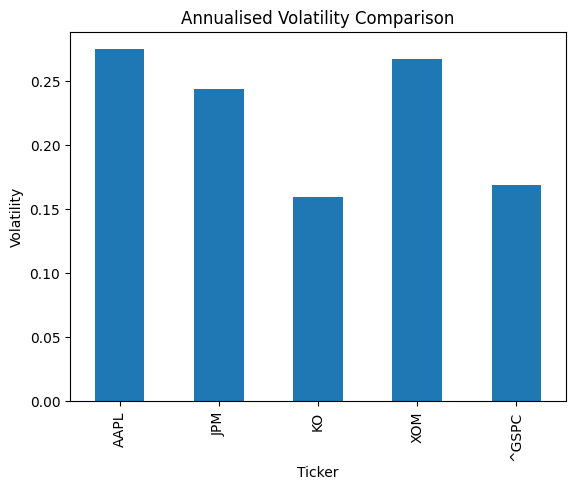

In [10]:
annual_volatility.plot(kind='bar')
plt.title('Annualised Volatility Comparison')
plt.ylabel('Volatility')
plt.savefig("returns_charts/annualised_volatility.png")

In [11]:
sharpe_ratio = annual_returns/annual_volatility
sharpe_ratio.round(3)

Ticker
AAPL     0.884
JPM      0.786
KO       0.829
XOM      1.195
^GSPC    0.815
dtype: float64

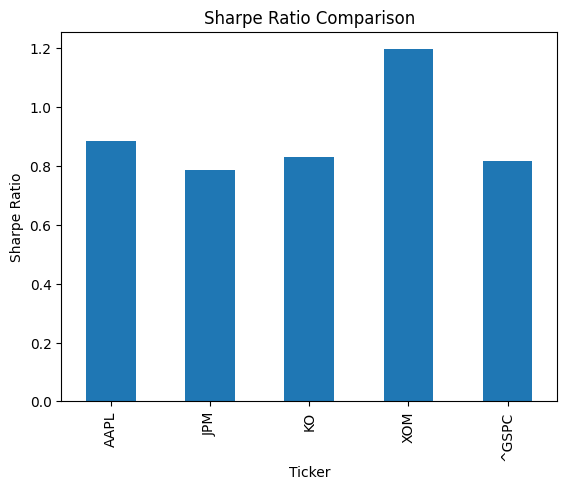

In [12]:
sharpe_ratio.plot(kind='bar')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Ticker')
plt.title('Sharpe Ratio Comparison')
plt.savefig("returns_charts/share_ratio.png")

In [13]:
compound = (1+returns).cumprod() - 1
final_compounded_return = compound.tail(1)
final_compounded_return.round(3)

Ticker,AAPL,JPM,KO,XOM,^GSPC
Date,,,,,
2026-05-19,1.445,1.063,0.741,2.316,0.769


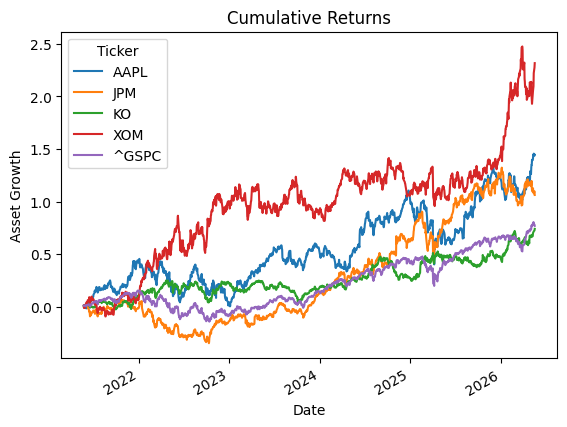

In [14]:
compound.plot()
plt.title('Cumulative Returns')
plt.ylabel('Asset Growth')
plt.savefig("returns_charts/cumulative_returns.png")

Exxon Mobil shows best compounded return over 5 years

Exxon Mobil shows best risk-adjusted return and highest Sharpe Ratio

Apple Was the most volatile asset with the most annualised volatility

Only Coca-Cola performed worse than the benchmark S&P 500 in terms of returns

S&P 500 had a better risk-adjusted return than both JP Morgan and Coca-Cola